In [2]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 6.7 MB/s eta 0:00:02
   ------- -------------------------------- 1.6/8.1 MB 3.8 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.1 MB 3.8 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.1 MB 3.4 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.1 MB 3.5 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.1 MB 3.5 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.1 MB 3.4 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.1 MB 3.5 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.1 MB 3.5 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 3.5 MB/s  0:00:02
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
    ------------------------

In [4]:
%pip install imblearn


   ---------------------------------------- 0/3 [sklearn-compat]
   ---------------------------------------- 0/3 [sklearn-compat]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs("outputs", exist_ok=True)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

In [2]:
df = pd.read_csv("C:/Users/satya/OneDrive/Documents/projects/aug_train.csv")
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0


In [3]:
df.shape

(19158, 14)

In [4]:
df.columns

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job', 'training_hours', 'target'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  str    
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  str    
 4   relevent_experience     19158 non-null  str    
 5   enrolled_university     18772 non-null  str    
 6   education_level         18698 non-null  str    
 7   major_discipline        16345 non-null  str    
 8   experience              19093 non-null  str    
 9   company_size            13220 non-null  str    
 10  company_type            13018 non-null  str    
 11  last_new_job            18735 non-null  str    
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  int64  
dtypes: float64(1), int64(3), str(10)
memory usage: 2.

In [6]:
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
train_df = pd.read_csv("C:/Users/satya/OneDrive/Documents/projects/aug_train.csv")
train_df.columns = train_df.columns.str.strip().str.lower()
train_df.columns

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job', 'training_hours', 'target'],
      dtype='str')

In [9]:
train_df["target"].value_counts()

target
0    14381
1     4777
Name: count, dtype: int64

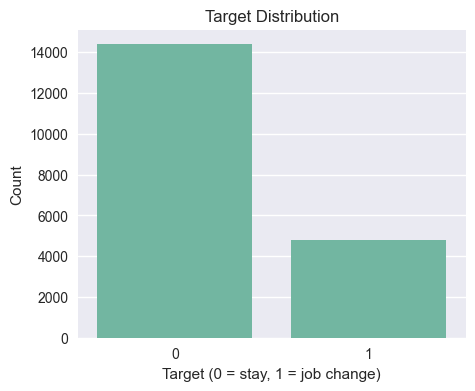

In [10]:
plt.figure(figsize=(5,4))
sns.countplot(x="target", data=train_df)
plt.title("Target Distribution")
plt.xlabel("Target (0 = stay, 1 = job change)")
plt.ylabel("Count")

plt.savefig("outputs/target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
df["city"].nunique(), df["gender"].nunique(), df["company_type"].nunique()

(123, 3, 6)

In [12]:
df.columns = df.columns.str.strip().str.lower()
df.columns

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job', 'training_hours', 'target'],
      dtype='str')

In [13]:
df = df.rename(columns={
    "relevent_experience": "relevant_experience",
    "city_development_index": "city_development_index",
    "major_discipline": "major_discipline"
})

In [14]:
df.dtypes

enrollee_id                 int64
city                          str
city_development_index    float64
gender                        str
relevant_experience           str
enrolled_university           str
education_level               str
major_discipline              str
experience                    str
company_size                  str
company_type                  str
last_new_job                  str
training_hours              int64
target                      int64
dtype: object

In [15]:
X = df.drop(columns=["target", "enrollee_id"])
y = df["target"]

In [16]:
cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
num_cols = X.select_dtypes(include=["number"]).columns.tolist()

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [18]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [19]:
log_model = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)
y_proba = log_model.predict_proba(X_test)[:, 1]

In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

Accuracy: 0.7502609603340292
Precision: 0.49930555555555556
Recall: 0.7528795811518325
F1 Score: 0.6004175365344467
ROC AUC: 0.7904641797101766
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      2877
           1       0.50      0.75      0.60       955

    accuracy                           0.75      3832
   macro avg       0.70      0.75      0.71      3832
weighted avg       0.80      0.75      0.76      3832



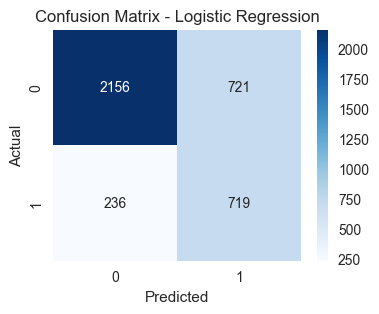

In [21]:
from sklearn.metrics import confusion_matrix

cm_log = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,3))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("outputs/confusion_matrix_logistic.png", dpi=300, bbox_inches="tight")
plt.show()

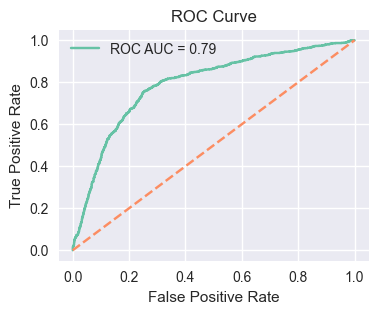

In [24]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(4,3))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, y_proba):.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("outputs/roc_curve_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
rf_model = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [26]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7693110647181628
Precision: 0.543451652386781
Recall: 0.4649214659685864
F1 Score: 0.5011286681715575
ROC AUC: 0.7794488514250046
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      2877
           1       0.54      0.46      0.50       955

    accuracy                           0.77      3832
   macro avg       0.69      0.67      0.68      3832
weighted avg       0.76      0.77      0.76      3832



In [27]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_rf)],
    "Precision": [precision_score(y_test, y_pred), precision_score(y_test, y_pred_rf)],
    "Recall": [recall_score(y_test, y_pred), recall_score(y_test, y_pred_rf)],
    "F1 Score": [f1_score(y_test, y_pred), f1_score(y_test, y_pred_rf)],
    "ROC AUC": [roc_auc_score(y_test, y_proba), roc_auc_score(y_test, y_proba_rf)]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.750261,0.499306,0.752880,0.600418,0.790464
1,Random Forest,0.769311,0.543452,0.464921,0.501129,0.779449


In [28]:
ohe = rf_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
feature_names = num_cols + list(ohe.get_feature_names_out(cat_cols))

importances = rf_model.named_steps["model"].feature_importances_
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feat_imp.head(15)

,feature,importance
1,training_hours,0.142509
0,city_development_index,0.103311
65,city_city_21,0.060988
168,company_size_50-99,0.054565
132,education_level_Graduate,0.024210
7,city_city_103,0.020533
164,experience_>20,0.019874
179,last_new_job_1,0.018892
178,company_type_Pvt Ltd,0.018383
131,enrolled_university_no_enrollment,0.015912


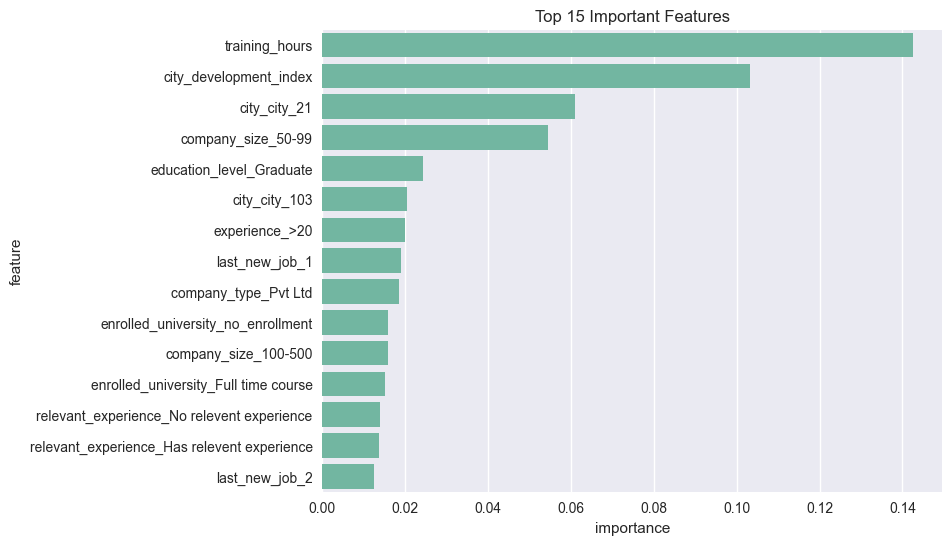

In [29]:
plt.figure(figsize=(8,6))
sns.barplot(data=feat_imp.head(15), x="importance", y="feature")
plt.title("Top 15 Important Features")
plt.savefig("outputs/feature_importance_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
import joblib

joblib.dump(rf_model, "hr_job_change_model.pkl")

['hr_job_change_model.pkl']

In [31]:
results.to_csv("model_comparison.csv", index=False)
feat_imp.to_csv("feature_importance.csv", index=False)